# Imports

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

# Load Final Dataset

In [2]:
dataset_path = "../data/processed/historical_model_ready_dataset.csv"

df = pd.read_csv(
    dataset_path,
    dtype={"county_fips": str},
    low_memory=False
)

df["county_fips"] = df["county_fips"].astype(str).str.zfill(5)

print("Dataset shape:")
print(df.shape)

display(df.head())

Dataset shape:
(3063, 202)


,GEO_ID,NAME,county_fips,B01001_001E,B01001_002E,B01001_003E,B01001_004E,B01001_005E,B01001_006E,B01001_007E,B01001_008E,B01001_009E,B01001_010E,B01001_011E,B01001_012E,B01001_013E,B01001_014E,B01001_015E,B01001_016E,B01001_017E,B01001_018E,B01001_019E,B01001_020E,B01001_021E,B01001_022E,B01001_023E,B01001_024E,B01001_025E,B01001_026E,B01001_027E,B01001_028E,B01001_029E,B01001_030E,B01001_031E,B01001_032E,B01001_033E,B01001_034E,B01001_035E,B01001_036E,B01001_037E,B01001_038E,B01001_039E,B01001_040E,B01001_041E,B01001_042E,B01001_043E,B01001_044E,B01001_045E,B01001_046E,B01001_047E,B01001_048E,B01001_049E,B02001_001E,B02001_002E,B02001_003E,B02001_004E,B02001_005E,B02001_006E,B02001_007E,B02001_008E,B02001_009E,B02001_010E,B15003_001E,B15003_002E,B15003_003E,B15003_004E,B15003_005E,B15003_006E,B15003_007E,B15003_008E,B15003_009E,B15003_010E,B15003_011E,B15003_012E,B15003_013E,B15003_014E,B15003_015E,B15003_016E,B15003_017E,B15003_018E,B15003_019E,B15003_020E,B15003_021E,B15003_022E,B15003_023E,B15003_024E,B15003_025E,B19013_001E,B17001_001E,B17001_002E,B17001_003E,B17001_004E,B17001_005E,B17001_006E,B17001_007E,B17001_008E,B17001_009E,B17001_010E,B17001_011E,B17001_012E,B17001_013E,B17001_014E,B17001_015E,B17001_016E,B17001_017E,B17001_018E,B17001_019E,B17001_020E,B17001_021E,B17001_022E,B17001_023E,B17001_024E,B17001_025E,B17001_026E,B17001_027E,B17001_028E,B17001_029E,B17001_030E,B17001_031E,B17001_032E,B17001_033E,B17001_034E,B17001_035E,B17001_036E,B17001_037E,B17001_038E,B17001_039E,B17001_040E,B17001_041E,B17001_042E,B17001_043E,B17001_044E,B17001_045E,B17001_046E,B17001_047E,B17001_048E,B17001_049E,B17001_050E,B17001_051E,B17001_052E,B17001_053E,B17001_054E,B17001_055E,B17001_056E,B17001_057E,B17001_058E,B17001_059E,B23025_001E,B23025_002E,B23025_003E,B23025_004E,B23025_005E,B23025_006E,B23025_007E,B25001_001E,state,county_name,totalvotes,democrat_votes,republican_votes,party_winner,dem_vote_share,total_population,median_income,total_housing_units,labor_force,unemployed,below_poverty,bachelors_degree,masters_degree,professional_degree,doctorate_degree,white_population,black_population,asian_population,higher_education_rate,poverty_rate,unemployment_rate,white_pct,black_pct,asian_pct,log_population,dem_share_2000,dem_share_2004,dem_share_2008,dem_share_2012,dem_share_2016,dem_share_2020,winner_2000,winner_2004,winner_2008,winner_2012,winner_2016,winner_2020,avg_dem_share_2000_2020,dem_wins_count_2000_2020,vote_volatility_2000_2020,swing_2016_2020,swing_2012_2020,swing_2000_2020,target_2024_party_winner,target_2024_dem_vote_share
0,0500000US01001,"Autauga County, Alabama",01001,55639,27052,1727,2156,1674,1208,553,395,225,1127,1789,1669,2043,1394,2015,1937,2025,628,804,429,699,1077,764,389,325,28587,1508,1569,1971,1330,625,224,306,1181,1870,1750,1850,2017,1990,1874,2080,835,800,496,836,1414,1066,358,637,55639,42150,10866,155,649,24,374,1421,346,1075,37860,275,0,0,35,0,17,25,3,124,117,313,718,1250,728,668,9663,2217,2194,5469,3323,6320,3399,504,498,57982.0,55181,8394,3417,257,55,362,244,104,226,357,340,407,479,413,142,31,4977,423,102,770,245,23,214,322,736,676,337,695,281,153,46787,23364,1454,424,2117,594,181,697,1934,3025,2997,3439,3009,2057,1436,23423,1073,152,1318,934,366,727,2014,2884,3174,3507,3005,2460,1809,44360,26025,25316,24580,736,709,18335,23697,ALABAMA,AUTAUGA,27770,7503.0,19838.0,0,0.270184,55639,57982.0,23697,26025,736,8394,6320,3399,504,498,42150,10866,649,0.192689,0.150865,0.028280,0.757562,0.195295,0.011664,10.926658,0.287192,0.236940,0.257730,0.265878,0.237697,0.270184,0.0,0.0,0.0,0.0,0.0,0.0,0.259270,0.0,0.019539,0.032487,0.004305,-0.017008,0.0,0.263039
1,0500000US01003,"Baldwin County, Alabama",01003,218289,105889,6082,5197,8289,4305,2406,1177,792,3581,6064,5977,6787,5979,6763,7037,7434,2273,5145,2762,3855,6007,4273,2163,1541,112400,5878,6362,6882,3998,2296,1245,1123,3113,6220,6126,7022,6623,7374,7396,7802,3702,5123,3058,4236,7008,4669,2556,2588,218289,186504,19153,1514,2033,10,3398,5677,1519,4158,155563,

# Remove Invalid Vote Shares Again (Safety Check)

In [3]:
df = df[
    df["target_2024_dem_vote_share"] <= 1
].copy()

df = df.dropna().copy()

print("Cleaned dataset shape:")
print(df.shape)

Cleaned dataset shape:
(3063, 202)


# Define Target Variable

In [4]:
target_column = "target_2024_party_winner"

print(df[target_column].value_counts())

print("\nClass distribution:")
print(df[target_column].value_counts(normalize=True))

target_2024_party_winner
0.0    2660
1.0     403
Name: count, dtype: int64

Class distribution:
target_2024_party_winner
0.0    0.86843
1.0    0.13157
Name: proportion, dtype: float64


# Remove Leakage Columns

In [6]:
leakage_columns = [
    
    # identifiers
    "GEO_ID",
    "NAME",
    "county_name",
    "county_fips",
    "state",
    
    # old election outputs
    "party_winner",
    "dem_vote_share",
    "democrat_votes",
    "republican_votes",
    "totalvotes",
    
    # 2024 targets
    "target_2024_party_winner",
    "target_2024_dem_vote_share",
    
    # direct 2024 leakage
    "dem_share_2024",
    "winner_2024"
]

X = df.drop(columns=leakage_columns, errors="ignore")

y = df[target_column]

print("Feature matrix shape:")
print(X.shape)

print("\nTarget shape:")
print(y.shape)

Feature matrix shape:
(3063, 190)

Target shape:
(3063,)


# Train/Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape:")
print(X_train.shape)

print("Testing set shape:")
print(X_test.shape)

Training set shape:
(2450, 190)
Testing set shape:
(613, 190)


# Feature Scaling

In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Scaling complete.")

Scaling complete.


# Logistic Regression Model

In [9]:
log_reg = LogisticRegression(
    class_weight="balanced",
    max_iter=5000,
    random_state=42
)

log_reg.fit(X_train_scaled, y_train)

print("Logistic Regression training complete.")

Logistic Regression training complete.


# Logistic Regression Predictions

In [10]:
y_pred_log = log_reg.predict(X_test_scaled)

y_prob_log = log_reg.predict_proba(X_test_scaled)[:, 1]

# Logistic Regression Evaluation

In [11]:
print("LOGISTIC REGRESSION RESULTS")
print("=" * 40)

accuracy = accuracy_score(y_test, y_pred_log)

precision = precision_score(y_test, y_pred_log)

recall = recall_score(y_test, y_pred_log)

f1 = f1_score(y_test, y_pred_log)

roc_auc = roc_auc_score(y_test, y_prob_log)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

LOGISTIC REGRESSION RESULTS
Accuracy: 0.9690
Precision: 0.8100
Recall: 1.0000
F1-score: 0.8950
ROC-AUC: 0.9968

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.96      0.98       532
         1.0       0.81      1.00      0.90        81

    accuracy                           0.97       613
   macro avg       0.91      0.98      0.94       613
weighted avg       0.97      0.97      0.97       613



# Confusion Matrix

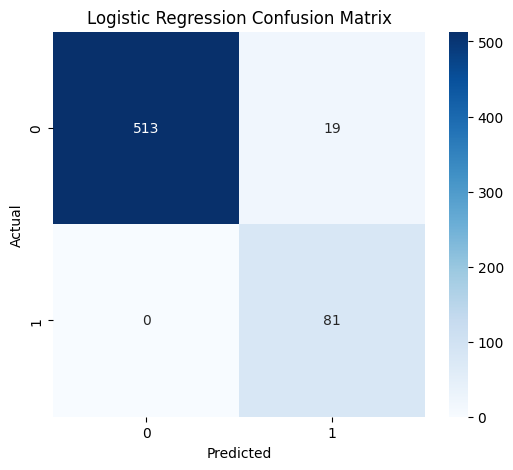

In [12]:
cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# Train Decision Tree

In [13]:
decision_tree = DecisionTreeClassifier(
    max_depth=6,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42
)

decision_tree.fit(X_train, y_train)

print("Decision Tree training complete.")

Decision Tree training complete.


# Decision Tree Predictions

In [14]:
y_pred_tree = decision_tree.predict(X_test)

y_prob_tree = decision_tree.predict_proba(X_test)[:, 1]

# Decision Tree Evaluation

In [15]:
print("DECISION TREE RESULTS")
print("=" * 40)

accuracy_tree = accuracy_score(y_test, y_pred_tree)

precision_tree = precision_score(y_test, y_pred_tree)

recall_tree = recall_score(y_test, y_pred_tree)

f1_tree = f1_score(y_test, y_pred_tree)

roc_auc_tree = roc_auc_score(y_test, y_prob_tree)

print(f"Accuracy: {accuracy_tree:.4f}")
print(f"Precision: {precision_tree:.4f}")
print(f"Recall: {recall_tree:.4f}")
print(f"F1-score: {f1_tree:.4f}")
print(f"ROC-AUC: {roc_auc_tree:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tree))

DECISION TREE RESULTS
Accuracy: 0.9788
Precision: 0.8696
Recall: 0.9877
F1-score: 0.9249
ROC-AUC: 0.9986

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.98      0.99       532
         1.0       0.87      0.99      0.92        81

    accuracy                           0.98       613
   macro avg       0.93      0.98      0.96       613
weighted avg       0.98      0.98      0.98       613



# Decision Tree Confusion Matrix

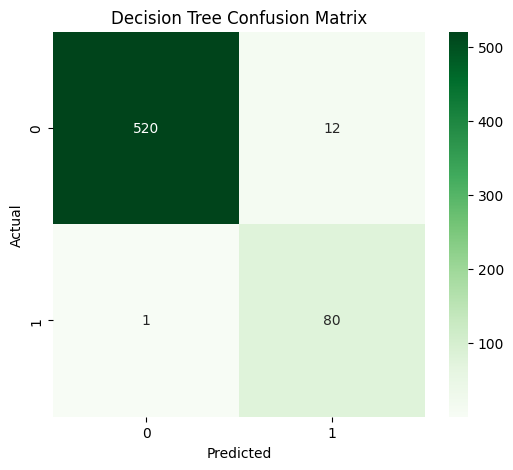

In [16]:
cm_tree = confusion_matrix(y_test, y_pred_tree)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_tree,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Decision Tree Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# Decision Tree Feature Importance

In [17]:
feature_importance_tree = pd.DataFrame({
    "Feature": X.columns,
    "Importance": decision_tree.feature_importances_
})

feature_importance_tree = feature_importance_tree.sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance_tree.head(15))

,Feature,Importance
177,dem_share_2020,0.988175
187,swing_2016_2020,0.004980
165,higher_education_rate,0.003919
82,B15003_024E,0.002274
188,swing_2012_2020,0.000501
55,B02001_007E,0.000136
5,B01001_006E,0.000016
6,B01001_007E,0.000000
8,B01001_009E,0.000000
7,B01001_008E,0.000000


# Visualize Top Tree Features

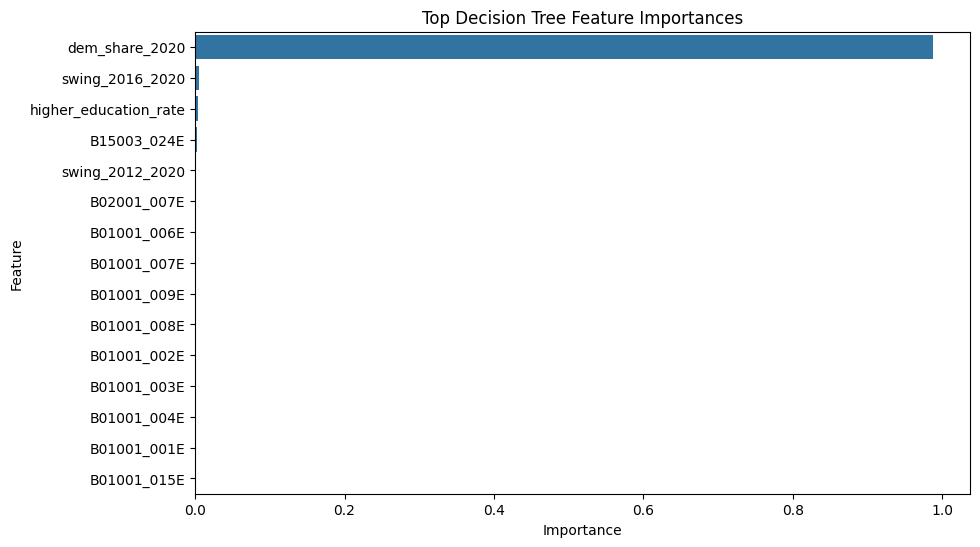

In [18]:
top_tree_features = feature_importance_tree.head(15)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_tree_features,
    x="Importance",
    y="Feature"
)

plt.title("Top Decision Tree Feature Importances")

plt.show()

# Train Random Forest

In [19]:
random_forest = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

random_forest.fit(X_train, y_train)

print("Random Forest training complete.")

Random Forest training complete.


# Random Forest Predictions

In [20]:
y_pred_rf = random_forest.predict(X_test)

y_prob_rf = random_forest.predict_proba(X_test)[:, 1]

# Random Forest Evaluation

In [21]:
print("RANDOM FOREST RESULTS")
print("=" * 40)

accuracy_rf = accuracy_score(y_test, y_pred_rf)

precision_rf = precision_score(y_test, y_pred_rf)

recall_rf = recall_score(y_test, y_pred_rf)

f1_rf = f1_score(y_test, y_pred_rf)

roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1-score: {f1_rf:.4f}")
print(f"ROC-AUC: {roc_auc_rf:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

RANDOM FOREST RESULTS
Accuracy: 0.9723
Precision: 0.8333
Recall: 0.9877
F1-score: 0.9040
ROC-AUC: 0.9972

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.97      0.98       532
         1.0       0.83      0.99      0.90        81

    accuracy                           0.97       613
   macro avg       0.92      0.98      0.94       613
weighted avg       0.98      0.97      0.97       613



# Random Forest Confusion Matrix

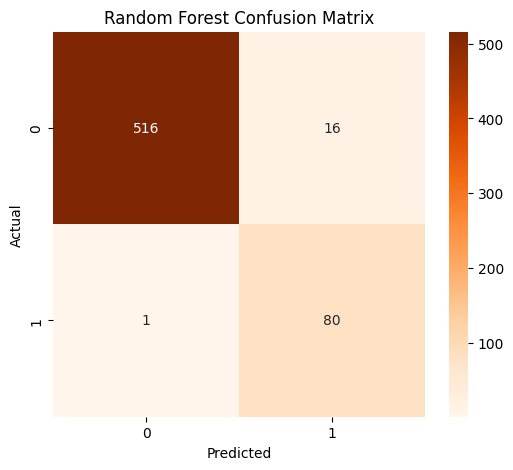

In [22]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# Random Forest Feature Importance

In [23]:
feature_importance_rf = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest.feature_importances_
})

feature_importance_rf = feature_importance_rf.sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance_rf.head(20))

,Feature,Importance
183,winner_2020,0.126864
182,winner_2016,0.091847
177,dem_share_2020,0.088821
176,dem_share_2016,0.078988
185,dem_wins_count_2000_2020,0.075993
174,dem_share_2008,0.060549
181,winner_2012,0.057910
184,avg_dem_share_2000_2020,0.051269
175,dem_share_2012,0.042094
189,swing_2000_2020,0.036757


# Plot Top RF Features

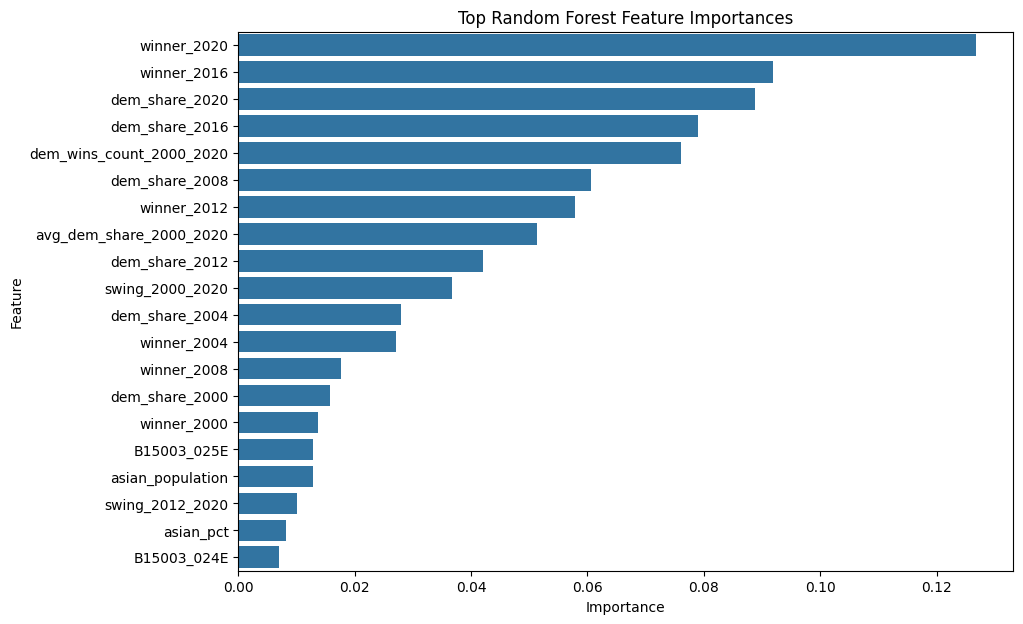

In [24]:
top_rf_features = feature_importance_rf.head(20)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_rf_features,
    x="Importance",
    y="Feature"
)

plt.title("Top Random Forest Feature Importances")

plt.show()

# Demographics-Only Ablation Experiment

In [25]:
historical_columns = [

    # historical vote shares
    "dem_share_2000",
    "dem_share_2004",
    "dem_share_2008",
    "dem_share_2012",
    "dem_share_2016",
    "dem_share_2020",

    # historical winners
    "winner_2000",
    "winner_2004",
    "winner_2008",
    "winner_2012",
    "winner_2016",
    "winner_2020",

    # historical trends
    "avg_dem_share_2000_2020",
    "dem_wins_count_2000_2020",
    "vote_volatility_2000_2020",

    # swing features
    "swing_2000_2020",
    "swing_2012_2020",
    "swing_2016_2020"
]

X_demo_only = X.drop(
    columns=historical_columns,
    errors="ignore"
)

print("Demographics-only feature shape:")
print(X_demo_only.shape)

Demographics-only feature shape:
(3063, 172)


# Train/Test Split

In [26]:
X_train_demo, X_test_demo, y_train_demo, y_test_demo = train_test_split(
    X_demo_only,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train_demo.shape)
print(X_test_demo.shape)

(2450, 172)
(613, 172)


# Scale Features

In [27]:
scaler_demo = StandardScaler()

X_train_demo_scaled = scaler_demo.fit_transform(X_train_demo)

X_test_demo_scaled = scaler_demo.transform(X_test_demo)

# Logistic Regression (Demographics Only)

In [28]:
log_reg_demo = LogisticRegression(
    class_weight="balanced",
    max_iter=5000,
    random_state=42
)

log_reg_demo.fit(X_train_demo_scaled, y_train_demo)

print("Demographics-only Logistic Regression complete.")

Demographics-only Logistic Regression complete.


# Predictions

In [29]:
y_pred_demo = log_reg_demo.predict(X_test_demo_scaled)

y_prob_demo = log_reg_demo.predict_proba(X_test_demo_scaled)[:, 1]

# Evaluation

In [30]:
print("DEMOGRAPHICS-ONLY LOGISTIC REGRESSION")
print("=" * 50)

accuracy_demo = accuracy_score(y_test_demo, y_pred_demo)

precision_demo = precision_score(y_test_demo, y_pred_demo)

recall_demo = recall_score(y_test_demo, y_pred_demo)

f1_demo = f1_score(y_test_demo, y_pred_demo)

roc_auc_demo = roc_auc_score(y_test_demo, y_prob_demo)

print(f"Accuracy: {accuracy_demo:.4f}")
print(f"Precision: {precision_demo:.4f}")
print(f"Recall: {recall_demo:.4f}")
print(f"F1-score: {f1_demo:.4f}")
print(f"ROC-AUC: {roc_auc_demo:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_demo, y_pred_demo))

DEMOGRAPHICS-ONLY LOGISTIC REGRESSION
Accuracy: 0.8777
Precision: 0.5227
Recall: 0.8519
F1-score: 0.6479
ROC-AUC: 0.9413

Classification Report:
              precision    recall  f1-score   support

         0.0       0.98      0.88      0.93       532
         1.0       0.52      0.85      0.65        81

    accuracy                           0.88       613
   macro avg       0.75      0.87      0.79       613
weighted avg       0.92      0.88      0.89       613



# Confusion Matrix

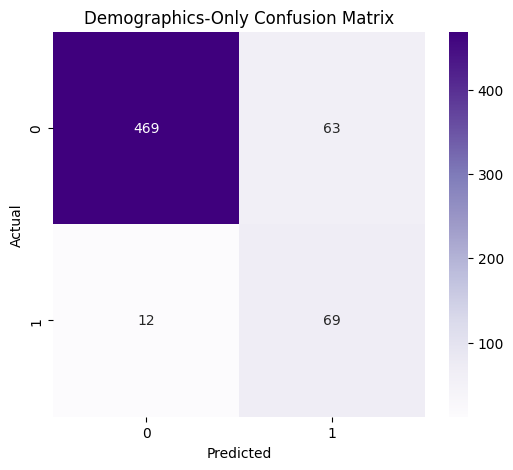

In [31]:
cm_demo = confusion_matrix(y_test_demo, y_pred_demo)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_demo,
    annot=True,
    fmt="d",
    cmap="Purples"
)

plt.title("Demographics-Only Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# Feature Importance Analysis

In [32]:
coefficients = pd.DataFrame({
    "Feature": X_demo_only.columns,
    "Coefficient": log_reg_demo.coef_[0]
})

coefficients["Absolute_Coefficient"] = coefficients["Coefficient"].abs()

coefficients = coefficients.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

display(coefficients.head(20))

,Feature,Coefficient,Absolute_Coefficient
165,higher_education_rate,2.239753,2.239753
69,B15003_011E,-2.016020,2.016020
150,B23025_007E,-1.793907,1.793907
91,B17001_007E,-1.715284,1.715284
19,B01001_020E,1.528604,1.528604
79,B15003_021E,1.487148,1.487148
31,B01001_032E,1.464691,1.464691
18,B01001_019E,1.422139,1.422139
23,B01001_024E,-1.400034,1.400034
148,B23025_005E,1.271968,1.271968


# Demographics-Only Decision Tree

In [33]:
decision_tree_demo = DecisionTreeClassifier(
    max_depth=6,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42
)

decision_tree_demo.fit(X_train_demo, y_train_demo)

print("Demographics-only Decision Tree complete.")

Demographics-only Decision Tree complete.


# Predictions

In [34]:
y_pred_tree_demo = decision_tree_demo.predict(X_test_demo)

y_prob_tree_demo = decision_tree_demo.predict_proba(X_test_demo)[:, 1]

# Evaluation

In [35]:
print("DEMOGRAPHICS-ONLY DECISION TREE")
print("=" * 50)

accuracy_tree_demo = accuracy_score(y_test_demo, y_pred_tree_demo)

precision_tree_demo = precision_score(y_test_demo, y_pred_tree_demo)

recall_tree_demo = recall_score(y_test_demo, y_pred_tree_demo)

f1_tree_demo = f1_score(y_test_demo, y_pred_tree_demo)

roc_auc_tree_demo = roc_auc_score(y_test_demo, y_prob_tree_demo)

print(f"Accuracy: {accuracy_tree_demo:.4f}")
print(f"Precision: {precision_tree_demo:.4f}")
print(f"Recall: {recall_tree_demo:.4f}")
print(f"F1-score: {f1_tree_demo:.4f}")
print(f"ROC-AUC: {roc_auc_tree_demo:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_demo, y_pred_tree_demo))

DEMOGRAPHICS-ONLY DECISION TREE
Accuracy: 0.8777
Precision: 0.5224
Recall: 0.8642
F1-score: 0.6512
ROC-AUC: 0.8784

Classification Report:
              precision    recall  f1-score   support

         0.0       0.98      0.88      0.93       532
         1.0       0.52      0.86      0.65        81

    accuracy                           0.88       613
   macro avg       0.75      0.87      0.79       613
weighted avg       0.92      0.88      0.89       613



# Confusion Matrix

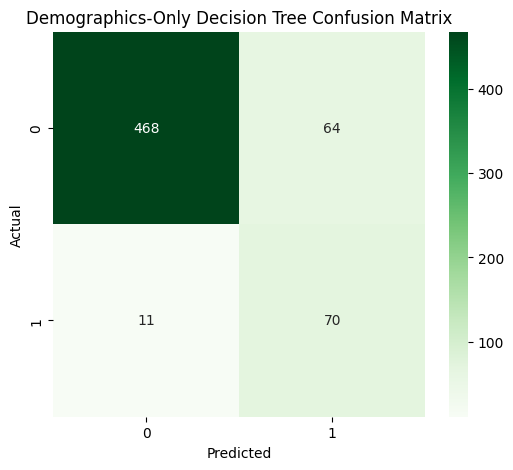

In [36]:
cm_tree_demo = confusion_matrix(y_test_demo, y_pred_tree_demo)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_tree_demo,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Demographics-Only Decision Tree Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# Feature Importance

In [37]:
feature_importance_tree_demo = pd.DataFrame({
    "Feature": X_demo_only.columns,
    "Importance": decision_tree_demo.feature_importances_
})

feature_importance_tree_demo = feature_importance_tree_demo.sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance_tree_demo.head(20))

,Feature,Importance
165,higher_education_rate,4.419871e-01
168,white_pct,3.243358e-01
53,B02001_005E,8.210702e-02
166,poverty_rate,3.836281e-02
94,B17001_010E,1.695943e-02
170,asian_pct,1.524555e-02
77,B15003_019E,1.457763e-02
14,B01001_015E,1.457136e-02
153,median_income,1.209221e-02
91,B17001_007E,8.173541e-03


# Demographics-Only Random Forest

In [38]:
random_forest_demo = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

random_forest_demo.fit(X_train_demo, y_train_demo)

print("Demographics-only Random Forest complete.")

Demographics-only Random Forest complete.


# Predictions

In [39]:
y_pred_rf_demo = random_forest_demo.predict(X_test_demo)

y_prob_rf_demo = random_forest_demo.predict_proba(X_test_demo)[:, 1]

# Evaluation

In [40]:
print("DEMOGRAPHICS-ONLY RANDOM FOREST")
print("=" * 50)

accuracy_rf_demo = accuracy_score(y_test_demo, y_pred_rf_demo)

precision_rf_demo = precision_score(y_test_demo, y_pred_rf_demo)

recall_rf_demo = recall_score(y_test_demo, y_pred_rf_demo)

f1_rf_demo = f1_score(y_test_demo, y_pred_rf_demo)

roc_auc_rf_demo = roc_auc_score(y_test_demo, y_prob_rf_demo)

print(f"Accuracy: {accuracy_rf_demo:.4f}")
print(f"Precision: {precision_rf_demo:.4f}")
print(f"Recall: {recall_rf_demo:.4f}")
print(f"F1-score: {f1_rf_demo:.4f}")
print(f"ROC-AUC: {roc_auc_rf_demo:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_demo, y_pred_rf_demo))

DEMOGRAPHICS-ONLY RANDOM FOREST
Accuracy: 0.9364
Precision: 0.7561
Recall: 0.7654
F1-score: 0.7607
ROC-AUC: 0.9636

Classification Report:
              precision    recall  f1-score   support

         0.0       0.96      0.96      0.96       532
         1.0       0.76      0.77      0.76        81

    accuracy                           0.94       613
   macro avg       0.86      0.86      0.86       613
weighted avg       0.94      0.94      0.94       613



# Confusion Matrix

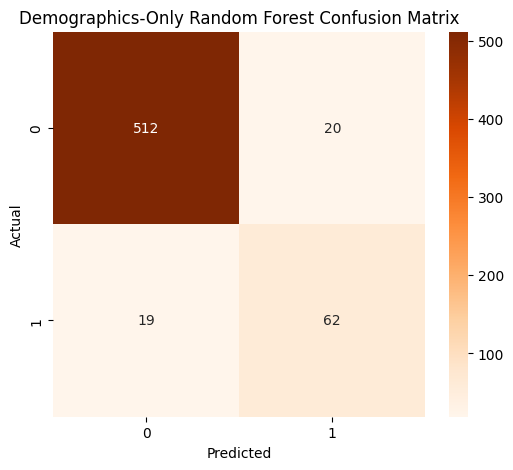

In [41]:
cm_rf_demo = confusion_matrix(y_test_demo, y_pred_rf_demo)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf_demo,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title("Demographics-Only Random Forest Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# Feature Importance

In [42]:
feature_importance_rf_demo = pd.DataFrame({
    "Feature": X_demo_only.columns,
    "Importance": random_forest_demo.feature_importances_
})

feature_importance_rf_demo = feature_importance_rf_demo.sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance_rf_demo.head(20))

,Feature,Importance
165,higher_education_rate,0.084446
168,white_pct,0.048384
169,black_pct,0.038245
83,B15003_025E,0.035419
53,B02001_005E,0.031107
82,B15003_024E,0.026701
161,doctorate_degree,0.026025
81,B15003_023E,0.025525
170,asian_pct,0.024264
160,professional_degree,0.022287
